In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import logging

from pathlib import Path
import anndata2ri
from bokeh.models import TabPanel, Tabs,ColorBar
from bokeh.plotting import show, output_file
from scipy.stats import median_abs_deviation
import seaborn as sns
import scrublet as scr
import seaborn as sns
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
from utils import interactive_embedding

%matplotlib inline

anndata2ri.activate()
%load_ext rpy2.ipython

rcb.logger.setLevel(logging.ERROR)

sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=False,
    figsize = (8,5)
)

pd.set_option("display.max_columns", None)
sc.settings.verbosity = 1

In [23]:
BATCH = 1
PT = "PT-185-B"
FILTERED_RAW = "filtered"

In [24]:
if BATCH==1:
    batch_path = Path("../data/narsad_cellRanger_outs/")
else:
    batch_path = Path()
    
adata = sc.read_10x_mtx(batch_path / f"{PT}" / f"{FILTERED_RAW}_feature_bc_matrix")

adata

AnnData object with n_obs × n_vars = 7908 × 33538
    var: 'gene_ids', 'feature_types'

In [25]:
FILTERED_RAW = "raw"
adata_raw = sc.read_10x_mtx(batch_path / f"{PT}" / f"{FILTERED_RAW}_feature_bc_matrix")
adata_raw

AnnData object with n_obs × n_vars = 737280 × 33538
    var: 'gene_ids'

In [26]:
adata.var_names_make_unique()
adata_raw.var_names_make_unique()


### 1) Highest expressed genes

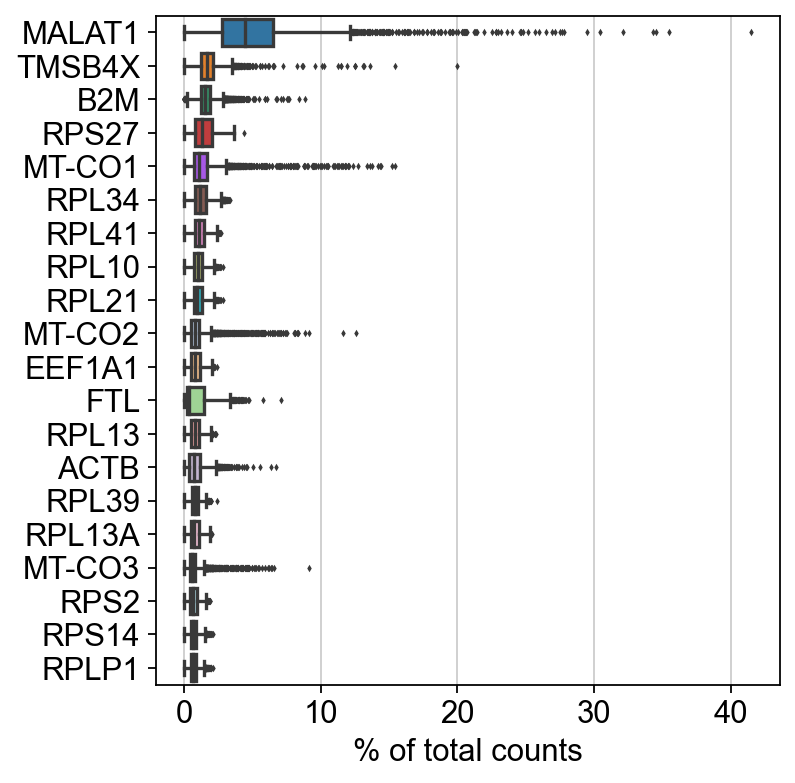

In [27]:
sc.pl.highest_expr_genes(adata, n_top=20)


#### Remove MALAT1

In [28]:
malat1 = adata.var_names.str.startswith('MALAT1')
keep = np.invert(malat1)
adata = adata[:,keep]

print(adata.n_obs, adata.n_vars)


7908 33537


### 2) Filter low quality cells

In [29]:
sc.pp.filter_cells(adata, min_genes=200)
adata

/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:140: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


AnnData object with n_obs × n_vars = 7900 × 33537
    obs: 'n_genes'
    var: 'gene_ids', 'feature_types'

### 3) Low quality reads

In [30]:
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes.
adata.var["hb"] = adata.var_names.str.contains(("^HB[^(P)]"))


In [31]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
adata

AnnData object with n_obs × n_vars = 7900 × 33537
    obs: 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [32]:
# p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
# #sc.pl.violin(adata, 'total_counts')
# p2 = sc.pl.violin(adata, "pct_counts_mt")
# p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [33]:

def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

In [34]:
adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5)
    | is_outlier(adata, "log1p_n_genes_by_counts", 5)
    | is_outlier(adata, "pct_counts_in_top_20_genes", 5)
)
adata.obs.outlier.value_counts()

outlier
False    7566
True      334
Name: count, dtype: int64

In [37]:
adata.obs["mt_outlier"] = is_outlier(adata, "pct_counts_mt", 3) | (
    adata.obs["pct_counts_mt"] > 8
)
adata.obs.mt_outlier.value_counts()

mt_outlier
False    6773
True     1127
Name: count, dtype: int64

In [38]:
print(f"Total number of cells: {adata.n_obs}")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

Total number of cells: 7900
Number of cells after filtering of low quality cells: 6644


In [39]:
# p1 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")
# sc.pl.highest_expr_genes(adata, n_top=20)


In [40]:
from utils import interactive_embedding

In [18]:
# sc.pp.normalize_per_cell(adata)
# sc.pp.log1p(adata) # R equivalent of NormalizeData

sc.tl.pca(adata, svd_solver="arpack")
n_pcs = len(adata.uns["pca"]["variance_ratio"])
print(f'Explained variance of first {n_pcs} PCs = ', adata.uns["pca"]['variance_ratio'].sum())
sc.pp.neighbors(adata, n_neighbors=20, n_pcs=50)
sc.tl.umap(adata)
# sc.pl.umap(adata, color=["MALAT1", "CD74"])

Explained variance of first 50 PCs =  0.798759496587799


/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8

### 4) Soup removal and doublet detection

In [41]:
adata_pp = adata.copy()
sc.pp.normalize_per_cell(adata_pp)
sc.pp.log1p(adata_pp)

In [42]:
sc.pp.pca(adata_pp)
sc.pp.neighbors(adata_pp)
sc.tl.leiden(adata_pp, key_added="soupx_groups")

# Preprocess variables for SoupX
soupx_groups = adata_pp.obs["soupx_groups"]

In [43]:
del adata_pp

cells = adata.obs_names
genes = adata.var_names
data = adata.X.T

adata_raw.var_names_make_unique()

malat1 = adata_raw.var_names.str.startswith('MALAT1')
keep = np.invert(malat1)
adata_raw = adata_raw[:,keep]
data_tod = adata_raw.X.T
del adata_raw

In [44]:
%%R -i data -i data_tod -i genes -i cells -i soupx_groups -o out 
library(SoupX)
# specify row and column names of data
rownames(data) = genes
colnames(data) = cells
# ensure correct sparse format for table of counts and table of droplets
data <- as(data, "sparseMatrix")
data_tod <- as(data_tod, "sparseMatrix")

# Generate SoupChannel Object for SoupX 
sc = SoupChannel(data_tod, data, calcSoupProfile = FALSE)

# Add extra meta data to the SoupChannel object
soupProf = data.frame(row.names = rownames(data), est = rowSums(data)/sum(data), counts = rowSums(data))
sc = setSoupProfile(sc, soupProf)
# Set cluster information in SoupChannel
sc = setClusters(sc, soupx_groups)

# Estimate contamination fraction
sc  = autoEstCont(sc, doPlot=FALSE)
# Infer corrected table of counts and rount to integer
out = adjustCounts(sc, roundToInt = TRUE)

In [45]:
adata.layers["counts"] = adata.X
adata.layers["soupX_counts"] = out.T
adata.X = adata.layers["soupX_counts"]

In [46]:
print(f"Total number of genes: {adata.n_vars}")

# Min 3 cells - filters out 0 count genes
sc.pp.filter_genes(adata, min_cells=3)
print(f"Number of genes after cell filter: {adata.n_vars}")

Total number of genes: 33537
Number of genes after cell filter: 15624


#### Doublet with `scDblFinder`

In [47]:
%%R
library(Seurat)

library(scater)
library(scDblFinder)
library(BiocParallel)

In [48]:
data_mat = adata.X.T.copy()


In [49]:
%%R -i data_mat -o doublet_score -o doublet_class

set.seed(123)
sce = scDblFinder(
    SingleCellExperiment(
        list(counts=data_mat),
    ) 
)
doublet_score = sce$scDblFinder.score
doublet_class = sce$scDblFinder.class

In [50]:
adata.obs["scDblFinder_score"] = doublet_score
adata.obs["scDblFinder_class"] = doublet_class
adata.obs['scDblFinder_class']  = adata.obs['scDblFinder_class'].astype("object")

adata.obs.scDblFinder_class.value_counts()

scDblFinder_class
singlet    6280
doublet     364
Name: count, dtype: int64

#### Doubles with scrublet

In [51]:
scrub = scr.Scrublet(adata.X, expected_doublet_rate = 0.076)
adata.obs['doublet_scores_scrublet'], adata.obs['predicted_doublets_scrublet'] = scrub.scrub_doublets(min_counts=2, min_cells=3, 
                                                          min_gene_variability_pctl=85, n_prin_comps=30)

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.27
Detected doublet rate = 3.5%
Estimated detectable doublet fraction = 62.6%
Overall doublet rate:
	Expected   = 7.6%
	Estimated  = 5.7%
Elapsed time: 3.2 seconds


In [52]:
# scrub.plot_histogram()

In [53]:
adata.obs['predicted_doublets_scrublet'].value_counts()


predicted_doublets_scrublet
False    6409
True      235
Name: count, dtype: int64

In [54]:
# adata.obs['predicted_doublets_scrublet'] =adata.obs['predicted_doublets_scrublet'].astype('str')


### 5) Normalization

#### log1p transform


In [55]:
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
# log1p transform
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

In [56]:
# import matplotlib.pyplot as plt
# fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
# axes[0].set_title("Total counts")
# p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
# axes[1].set_title("Shifted logarithm")
# plt.show()

#### scran

In [57]:
from scipy.sparse import csr_matrix, issparse


In [58]:
%%R
library(scran)
library(BiocParallel)

In [59]:
# Preliminary clustering for differentiated normalisation
adata_pp = adata.copy()
sc.pp.normalize_total(adata_pp)
sc.pp.log1p(adata_pp)
sc.pp.pca(adata_pp, n_comps=15)
sc.pp.neighbors(adata_pp)
sc.tl.leiden(adata_pp, key_added="groups")

In [60]:
data_mat = adata_pp.X.T
# convert to CSC if possible. See https://github.com/MarioniLab/scran/issues/70
if issparse(data_mat):
    if data_mat.nnz > 2**31 - 1:
        data_mat = data_mat.tocoo()
    else:
        data_mat = data_mat.tocsc()
ro.globalenv["data_mat"] = data_mat
ro.globalenv["input_groups"] = adata_pp.obs["groups"]

In [61]:
del adata_pp

In [62]:
%%R -o size_factors

size_factors = sizeFactors(
    computeSumFactors(
        SingleCellExperiment(
            list(counts=data_mat)), 
            clusters = input_groups,
            min.mean = 0.1,
            BPPARAM = MulticoreParam()
    )
)

In [63]:
adata.obs["size_factors"] = size_factors
scran = adata.X / adata.obs["size_factors"].values[:, None]
adata.layers["scran_normalization"] = csr_matrix(sc.pp.log1p(scran))

In [64]:
# import matplotlib.pyplot as plt
# fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
# axes[0].set_title("Total counts")
# p2 = sns.histplot(
#     adata.layers["scran_normalization"].sum(1), bins=100, kde=False, ax=axes[1]
# )
# axes[1].set_title("log1p with Scran estimated size factors")
# plt.show()

#### Analytic Pearson residual

In [65]:
# from scipy.sparse import csr_matrix, issparse

# analytic_pearson = sc.experimental.pp.normalize_pearson_residuals(adata, inplace=False)
# adata.layers["analytic_pearson_residuals"] = csr_matrix(analytic_pearson["X"])

In [66]:
# fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
# axes[0].set_title("Total counts")
# p2 = sns.histplot(
#     adata.layers["analytic_pearson_residuals"].sum(1), bins=100, kde=False, ax=axes[1]
# )
# axes[1].set_title("Analytic Pearson residuals")
# plt.show()

In [67]:
# sc.experimental.pp.recipe_pearson_residuals(adata)

### sctransform v2

In [68]:
# %%R -i adata
# # install sctransform >= 0.3.3
# # invoke sctransform - requires Seurat>=4.1
# seu <- CreateSeuratObject(adata, assay="RNA")
# adata <- SCTransform(adata, vst.flavor = "v2")

### 6) Feature selection

#### Deviance

In [69]:
%%R
library(scry)


In [70]:
import rpy2.robjects as ro

adata_deviance = adata.copy()
ro.globalenv["adata_deviance"] = adata_deviance

In [77]:
adata_deviance.X

<6644x15624 sparse matrix of type '<class 'numpy.float64'>'
	with 5772839 stored elements in Compressed Sparse Row format>

In [72]:
%%R 
sce = devianceFeatureSelection(adata_deviance, assay="X")

In [73]:
labels = ["total_counts", "n_genes_by_counts", "pct_counts_mt", 'pct_counts_ribo', 'scDblFinder_score','scDblFinder_class','doublet_scores_scrublet', 'predicted_doublets_scrublet']


In [74]:
ro.r("rowData(sce)")

,gene_ids,feature_types,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,binomial_deviance
AL627309.1,ENSG00000238009,Gene Expression,0,0,0,9,0.001139,0.001139,99.886076,9.0,2.302585,8,108.346748
AL669831.5,ENSG00000237491,Gene Expression,0,0,0,194,0.024937,0.024631,97.544304,197.0,5.288267,151,1173.853498
LINC00115,ENSG00000225880,Gene Expression,0,0,0,31,0.003924,0.003916,99.607595,31.0,3.465736,24,270.054868
FAM41C,ENSG00000230368,Gene Expression,0,0,0,97,0.012405,0.012329,98.772152,98.0,4.595120,86,763.288807
NOC2L,ENSG00000188976,Gene Expression,0,0,0,617,0.082405,0.079185,92.189873,651.0,6.480044,493,2631.522439
...,...,...,...,...,...,...,...,...,...,...,...,...,...
AL592183.1,ENSG00000273748,Gene Expression,0,0,0,614,0.081646,0.078484,92.227848,645.0,6.470799,526,2818.826482
AC007325.4,ENSG00000278817,Gene Expression,0,0,0,48,0.006076,0.006058,99.392405,48.0,3.891820,38,389.569913
AL354822.1,ENSG00000278384,Gene Expression,0,0,0,8,0.001013,0.001012,99.898734,8.0,2.197225,8,103.518254
AC004556.1,ENSG00000276345,Gene Expression,0,0,0,10,0.001266,0.001265,99.873418,10.0,2.397895,7,97.104003


/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


[<Axes: title={'center': 'total_counts'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'n_genes_by_counts'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'pct_counts_mt'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'pct_counts_ribo'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'scDblFinder_score'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'scDblFinder_class'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'doublet_scores_scrublet'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'predicted_doublets_scrublet'}, xlabel='UMAP1', ylabel='UMAP2'>]

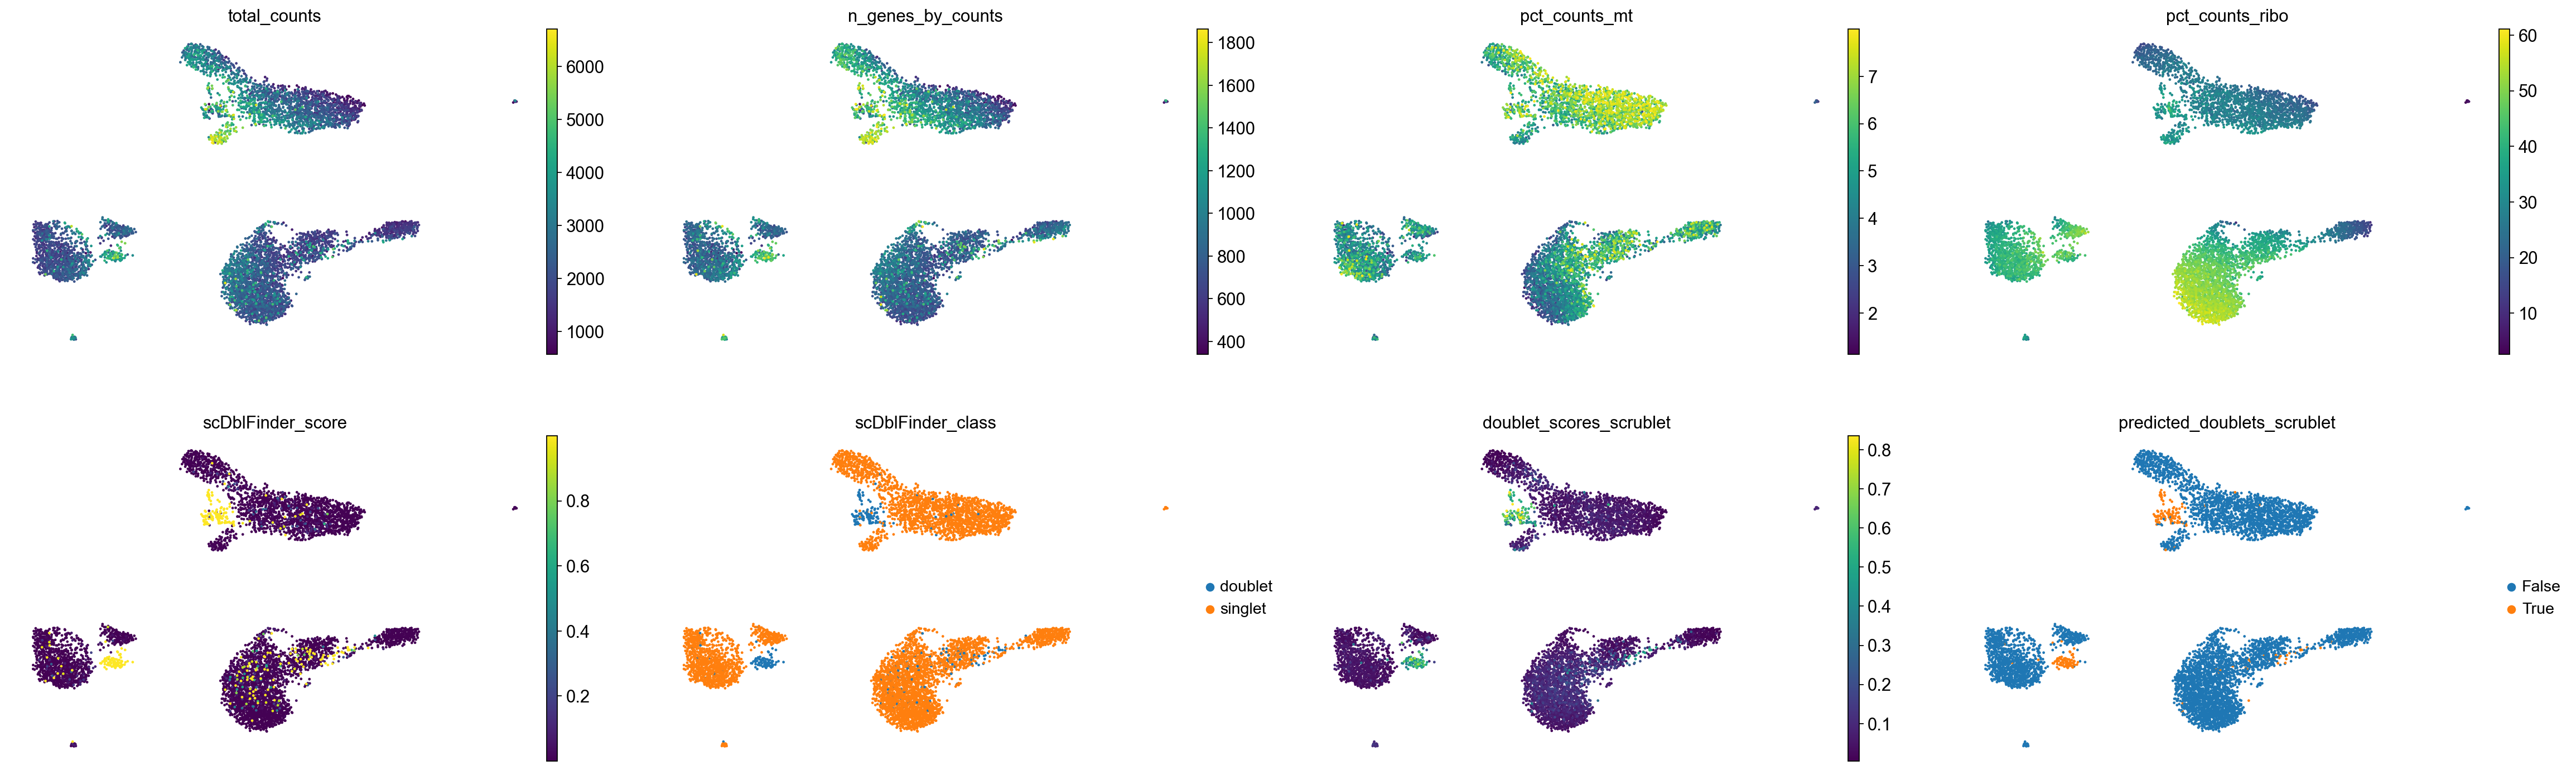

In [76]:
binomial_deviance = ro.r("rowData(sce)$binomial_deviance").T
idx = binomial_deviance.argsort()[-3000:]
mask = np.zeros(adata_deviance.var_names.shape, dtype=bool)
mask[idx] = True

adata_deviance.var["highly_deviant"] = mask
adata_deviance.var["binomial_deviance"] = binomial_deviance
adata_deviance.X = adata.layers["log1p_norm"]

adata_deviance.var["highly_variable"] = adata_deviance.var["highly_deviant"]

adata_deviance.obs['predicted_doublets_scrublet'] =adata_deviance.obs['predicted_doublets_scrublet'].astype('str')

sc.pp.highly_variable_genes(adata, layer="scran_normalization")
sc.tl.pca(adata_deviance, svd_solver="arpack", n_comps=50, use_highly_variable=True)


sc.pp.neighbors(adata_deviance)
sc.tl.umap(adata_deviance)
sc.pl.umap(adata_deviance, color=labels, show=False, return_fig=False)


In [ ]:
adata_deviance

#### Seurat highly variables

In [ ]:

# adata_seurat = adata.copy()
# adata_seurat.X = adata_seurat.layers["log1p_norm"]

# sc.pp.normalize_total(adata_seurat)
# sc.pp.log1p(adata_seurat)

# sc.pp.highly_variable_genes(adata_seurat, n_top_genes=3000)
# sc.tl.pca(adata_seurat, svd_solver="arpack", n_comps=50, use_highly_variable=True)
# n_pcs = len(adata_seurat.uns["pca"]['variance_ratio'])
# print(f'Explained variance of first {n_pcs} PCs = ', adata_seurat.uns["pca"]['variance_ratio'].sum())

# sc.pp.neighbors(adata_seurat)
# sc.tl.umap(adata_seurat)
# # sc.pl.umap(adata_seurat, color=labels, show=False, return_fig=False)

#### Seurat v3 highly variables

In [ ]:
# adata_seuratv3 = adata.copy()
# sc.pp.normalize_total(adata_seuratv3)

# sc.pp.highly_variable_genes(adata_seuratv3, flavor='seurat_v3', n_top_genes=3000)
# sc.pp.log1p(adata_seuratv3)

# sc.tl.pca(adata_seuratv3, svd_solver="arpack", n_comps=50, use_highly_variable=True)
# print(f'Explained variance of first {n_pcs} PCs = ', adata_seuratv3.uns["pca"]['variance_ratio'].sum())

# sc.pp.neighbors(adata_seuratv3)
# sc.tl.umap(adata_seuratv3)
# # sc.pl.umap(adata_seuratv3, color=labels, show=False, return_fig=False)

#### pearson residuals highly variables

In [ ]:
# adata_pearson = adata.copy()
# # adata_pearson.X = adata_pearson.layers["analytic_pearson_residuals"]
# sc.pp.normalize_total(adata_pearson)
# sc.pp.log1p(adata_pearson)

# sc.experimental.pp.highly_variable_genes(
#         adata_pearson, flavor="pearson_residuals", n_top_genes=3000
#     )

# sc.tl.pca(adata_pearson, svd_solver="arpack", n_comps=50, use_highly_variable=True)
# print(f'Explained variance of first {n_pcs} PCs = ', adata_pearson.uns["pca"]['variance_ratio'].sum())

# sc.pp.neighbors(adata_pearson)
# sc.tl.umap(adata_pearson)
# # sc.pl.umap(adata_pearson, color=labels, show=False, return_fig=False)




In [78]:
adata_deviance.obs['scDblFinder_class'] = adata_deviance.obs['scDblFinder_class'].astype('str')
adata_deviance.obs['predicted_doublets_scrublet'] =adata_deviance.obs['predicted_doublets_scrublet'].astype('str')


In [79]:
# sc.tl.pca(adata, svd_solver="arpack", n_comps=50, use_highly_variable=False)
# n_pcs = len(adata.uns["pca"]['variance_ratio'])
# print(f'Explained variance of first {n_pcs} PCs = ', adata.uns["pca"]['variance_ratio'].sum())

# sc.pp.neighbors(adata)
# sc.tl.umap(adata)
# sc.pl.umap(adata, color=labels, show=False, return_fig=False)

In [80]:
labels = ["total_counts", "n_genes_by_counts", "pct_counts_mt", 'pct_counts_ribo', 'scDblFinder_score','scDblFinder_class','doublet_scores_scrublet', 'predicted_doublets_scrublet']


In [81]:
tabs = []

for label in labels:
    tabs.append(TabPanel(child=interactive_embedding(adata_deviance, label), title=label))


# tabs.append(TabPanel(child=interactive_embedding(adata_deviance, "total_counts"), title="Deviance FS"))
# tabs.append(TabPanel(child=interactive_embedding(adata_seurat, "total_counts"), title="Seurat FS"))
# tabs.append(TabPanel(child=interactive_embedding(adata_seuratv3, "total_counts"), title="Seurat3 FS"))
# tabs.append(TabPanel(child=interactive_embedding(adata_pearson, "total_counts"), title="Pearson FS"))

p = Tabs(tabs=tabs)
output_file(f"../QC_plots/{PT}_QC.html")
# 
show(p)

total_counts
n_genes_by_counts
pct_counts_mt
pct_counts_ribo
scDblFinder_score
scDblFinder_class
doublet_scores_scrublet
predicted_doublets_scrublet
